In [1]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from joblib import Parallel, delayed
import Conor as c

# Reward 1

In [2]:
import importlib
importlib.reload(c)

<module 'Conor' from '/workspaces/Research-Skills-for-Financial-Mathematics/Conor.py'>

In [3]:
from scipy import stats

def compute_regret_slopes(results, scalings, v_star, fit_start=500):
    records, regret_dict = [], {}
    for s in scalings:
        label   = f"scaling={s}"
        vpi     = results[label]["vpi"]
        eps     = np.arange(1, len(vpi) + 1)
        cum_reg = np.cumsum(np.maximum(v_star - vpi, 0.0))
        regret_dict[label] = cum_reg
        mask    = (eps >= fit_start) & (cum_reg > 0)
        if mask.sum() < 10:
            records.append({"scaling": s, "alpha": np.nan, "r_squared": np.nan})
            continue
        slope, _, r, _, _ = stats.linregress(np.log(eps[mask]), np.log(cum_reg[mask]))
        records.append({"scaling": s, "alpha": round(slope, 4), "r_squared": round(r**2, 4)})
    return pd.DataFrame(records), regret_dict

In [4]:
# Bellman solver — run once to get V*(x0) for this reward
cfg_r1 = c.ExpConfig(
    starting_state=4.0,
    action_lo=-5.0,
    action_hi=5.0,
    rho=10.0,
    reward_step_fn=c.reward_quadratic_asymmetric,
)
solver_r1 = c.BellmanSolverScalar(cfg_r1, n_state=201, n_action=201, n_quad=41)
solver_r1.solve()
V_STAR_R1 = solver_r1.get_value(cfg_r1.starting_state)
print(f"V*(x0) = {V_STAR_R1:.4f}")   # expect ≈ 0.0

V*(x0) = 0.0040


In [5]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]
#scalings = [5]
configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results_sweep = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -36.479

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -39.528

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -35.733

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -30.010

--- Running: scaling=1 ---
    Done. Final mean VPI: -21.081

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.968

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.678

--- Running: scaling=50 ---
    Done. Final mean VPI: -59.704

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.733

--- Running: scaling=500 ---
    Done. Final mean VPI: -149.971


In [6]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results_sweep[label]["vpi"]
    arms = results_sweep[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-72681.017428,-36.478955,217.6,217.600
1,0.05,-77438.478296,-39.527682,218.8,218.728
2,0.10,-70852.066054,-35.733299,217.3,217.198
3,0.50,-60327.117140,-30.010158,217.3,217.300
4,1.00,-44123.456409,-21.081461,218.8,218.281
5,5.00,-15178.016841,-3.968112,225.1,223.495
6,10.00,-14000.348674,-3.678060,219.4,217.708
7,50.00,-135857.864768,-59.704247,214.3,214.015
8,100.00,-217898.143732,-100.733197,212.2,210.571
9,500.00,-280959.747458,-149.970519,217.0,217.000


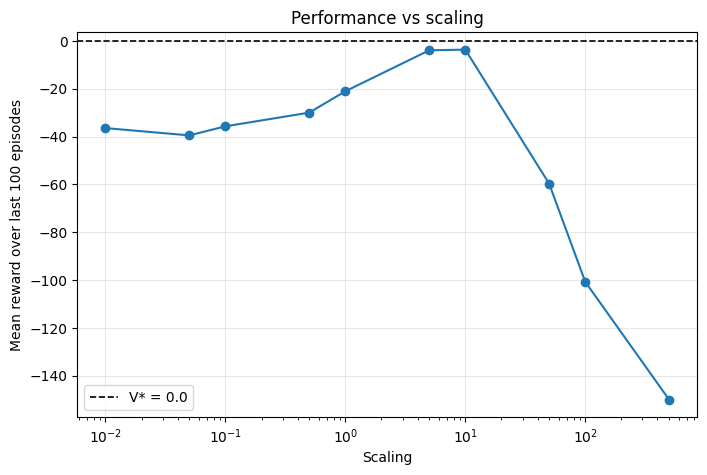

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.axhline(V_STAR_R1, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R1:.1f}')
plt.legend()
plt.show()

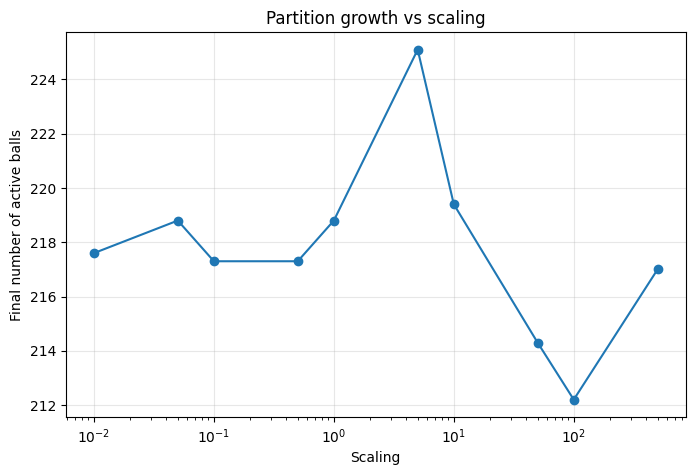

In [8]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

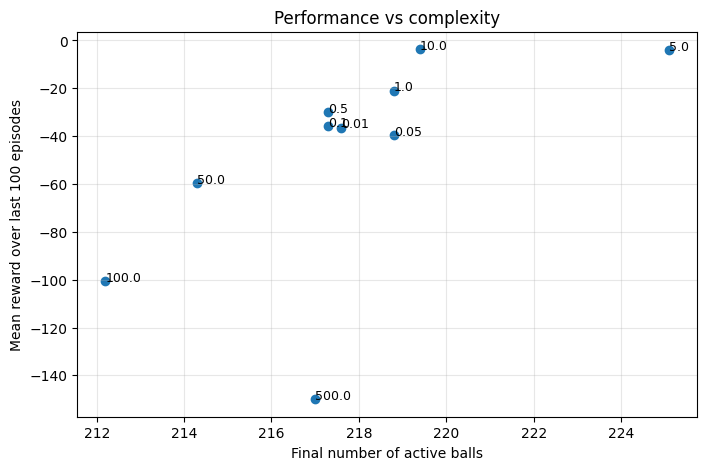

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: -33.869

--- Running: scaling=5 ---
    Done. Final mean VPI: -4.060

--- Running: scaling=100 ---
    Done. Final mean VPI: -99.458


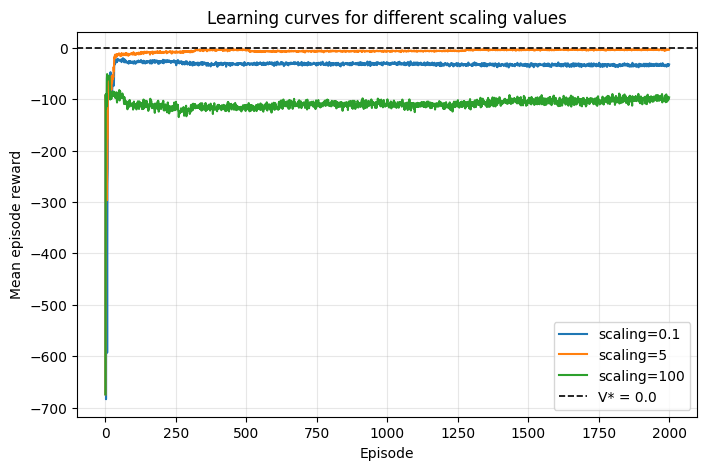

In [ ]:
chosen_scalings = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results_chosen = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results_chosen[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")
plt.axhline(V_STAR_R1, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R1:.1f}')
plt.title("Learning curves for different scaling values")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

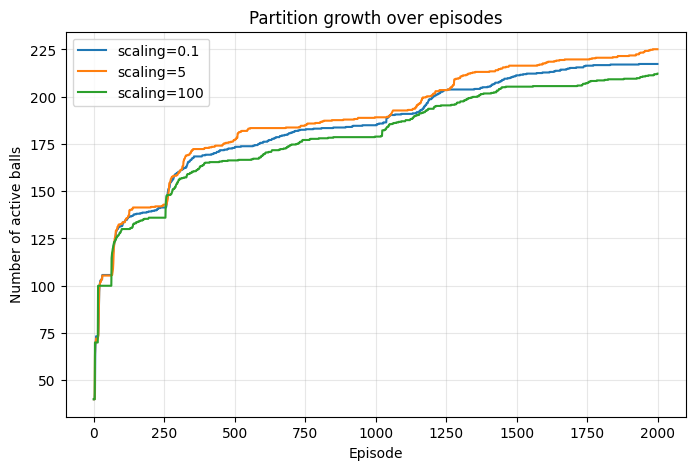

In [11]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results_sweep[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

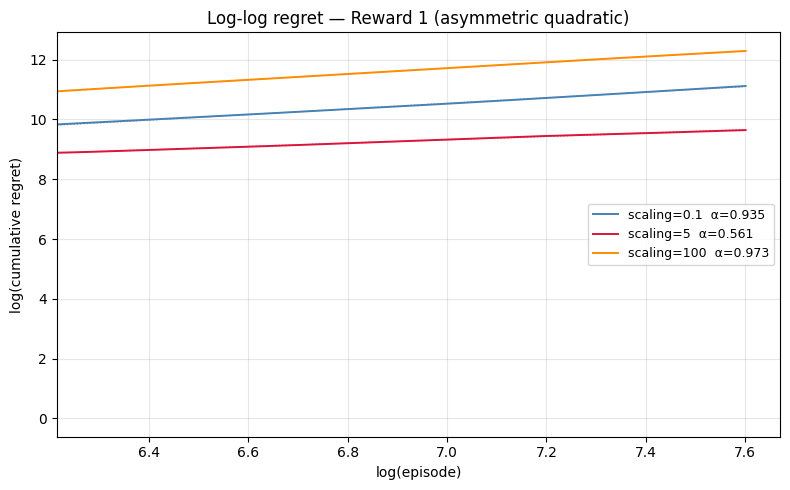

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
colours = {0.1: "steelblue", 5: "crimson", 100: "darkorange"}

for s in chosen_scalings:
    vpi     = results_chosen[f"scaling={s}"]["vpi"]
    eps     = np.arange(1, len(vpi) + 1)
    cum_reg = np.cumsum(np.maximum(V_STAR_R1 - vpi, 0.0))
    mask    = (eps >= 500) & (cum_reg > 0)
    lx, ly  = np.log(eps[mask]), np.log(cum_reg[mask])
    slope, intercept, _, _, _ = stats.linregress(lx, ly)
    ax.plot(lx, ly, lw=1.4, color=colours[s], label=f"scaling={s}  α={slope:.3f}")
    ax.plot(lx, slope*lx + intercept, lw=0.9, color=colours[s], ls=":", alpha=0.8)

ax.axhline(0, color="white", alpha=0)   # fix ylim
ax.set_xlim(left=np.log(500))
ax.set_xlabel("log(episode)")
ax.set_ylabel("log(cumulative regret)")
ax.set_title("Log-log regret — Reward 1 (asymmetric quadratic)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

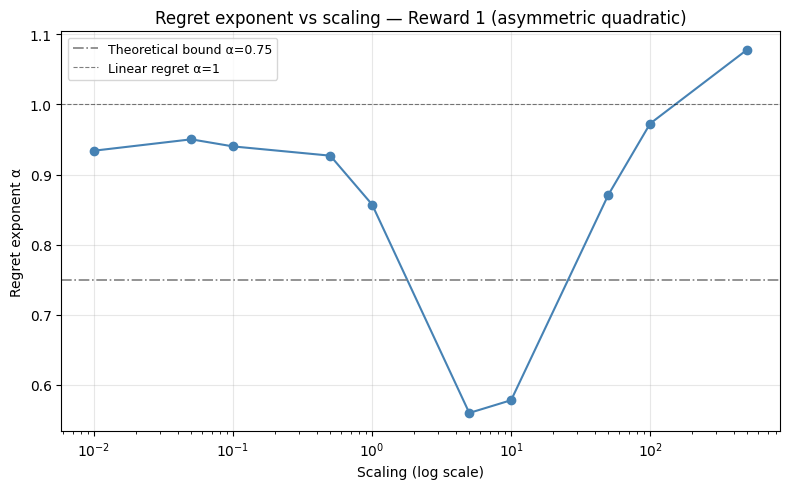

In [13]:
slopes_r1, _ = compute_regret_slopes(results_sweep, scalings, V_STAR_R1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(slopes_r1["scaling"], slopes_r1["alpha"], marker="o", color="steelblue", lw=1.5)
ax.axhline(0.75, color="gray", ls="-.", lw=1.2, label="Theoretical bound α=0.75")
ax.axhline(1.0,  color="black", ls="--", lw=0.8, alpha=0.5, label="Linear regret α=1")
ax.set_xscale("log")
ax.set_xlabel("Scaling (log scale)")
ax.set_ylabel("Regret exponent α")
ax.set_title("Regret exponent vs scaling — Reward 1 (asymmetric quadratic)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reward 2


In [ ]:
importlib.reload(c)
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: 92.598

--- Running: scaling=0.05 ---
    Done. Final mean VPI: 92.652

--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.063

--- Running: scaling=0.5 ---
    Done. Final mean VPI: 95.457

--- Running: scaling=1 ---
    Done. Final mean VPI: 97.240

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.089

--- Running: scaling=10 ---
    Done. Final mean VPI: 83.152

--- Running: scaling=50 ---
    Done. Final mean VPI: 57.932

--- Running: scaling=100 ---
    Done. Final mean VPI: 45.689

--- Running: scaling=500 ---
    Done. Final mean VPI: 36.498


In [46]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,185640.051680,92.598100,220.6,219.184
1,0.05,185834.821700,92.652033,219.4,217.951
2,0.10,186697.174160,93.062786,218.8,217.315
3,0.50,190854.430669,95.457347,220.0,218.323
4,1.00,193492.413931,97.239675,219.4,217.699
5,5.00,180918.325441,91.088684,208.3,208.069
6,10.00,164100.239988,83.151768,209.5,208.483
7,50.00,113823.956097,57.931826,211.6,211.600
8,100.00,91373.152053,45.688554,213.1,213.100
9,500.00,79744.457007,36.497663,217.0,217.000


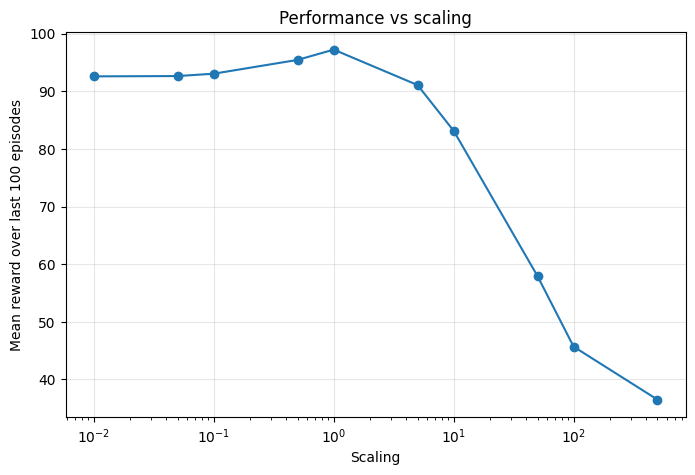

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

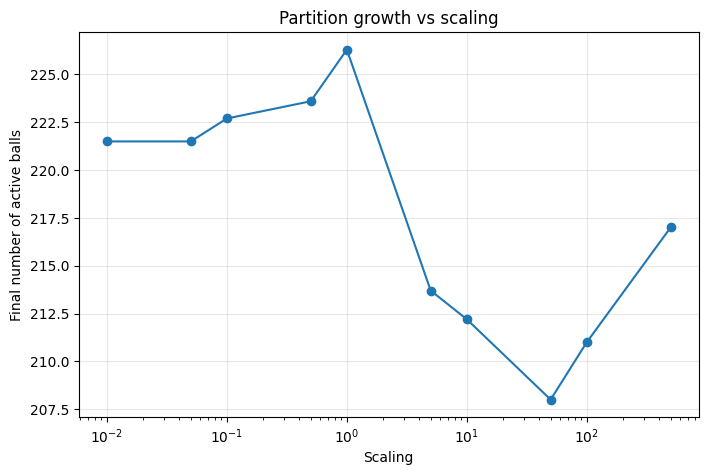

In [30]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

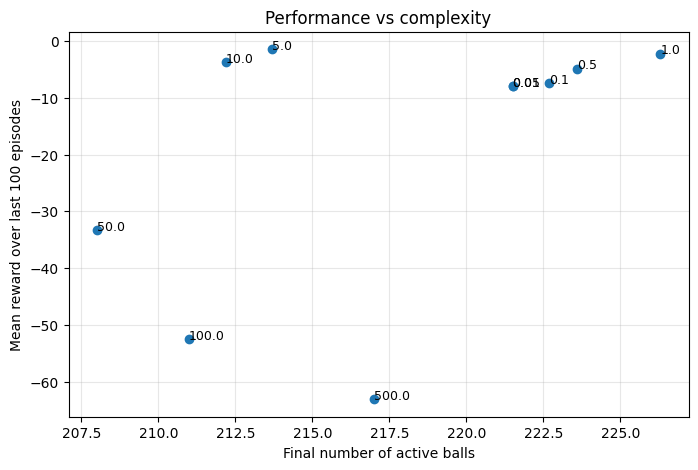

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.298

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.274

--- Running: scaling=100 ---
    Done. Final mean VPI: 44.868


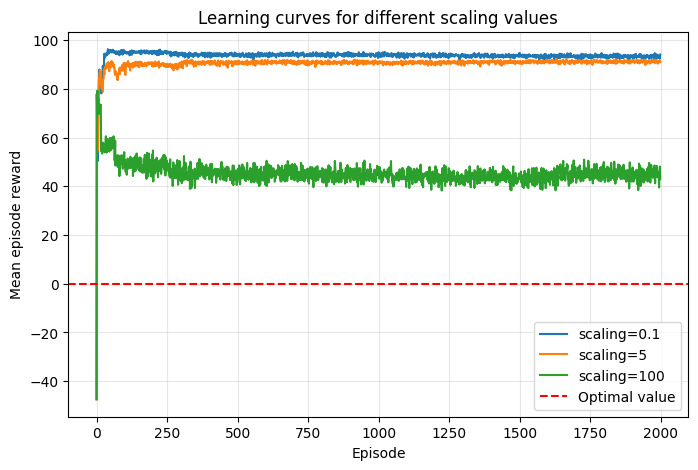

In [ ]:
chosen_scalings = [0.1, 5, 100]



configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")
plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

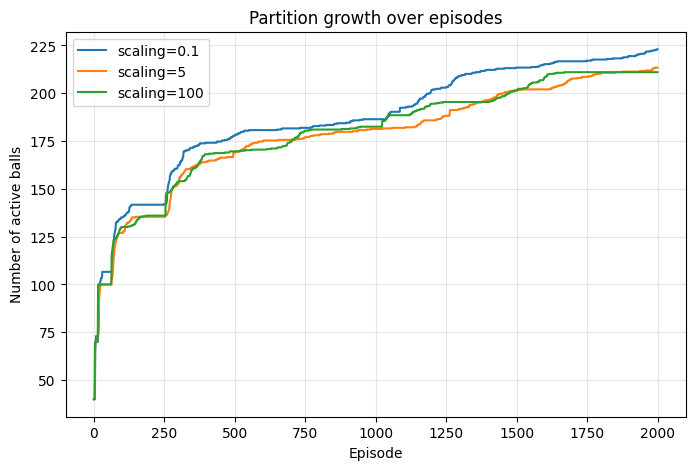

In [33]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Reward 3

In [34]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -42.483

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -41.932

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -41.404

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -34.968

--- Running: scaling=1 ---
    Done. Final mean VPI: -30.314

--- Running: scaling=5 ---
    Done. Final mean VPI: -8.964

--- Running: scaling=10 ---
    Done. Final mean VPI: -4.852

--- Running: scaling=50 ---
    Done. Final mean VPI: -30.342

--- Running: scaling=100 ---
    Done. Final mean VPI: -67.733

--- Running: scaling=500 ---
    Done. Final mean VPI: -213.679


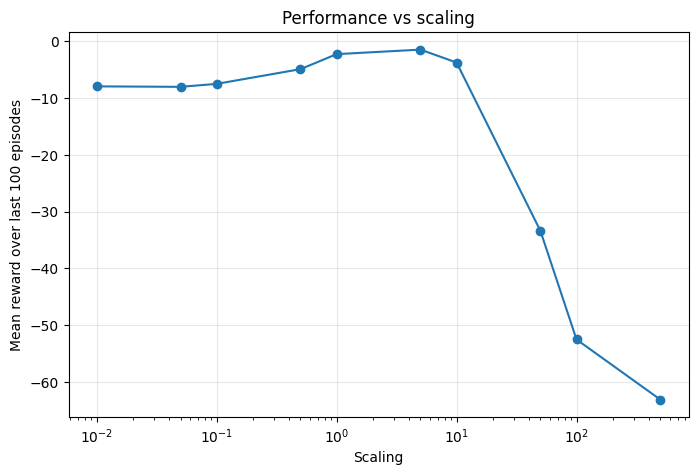

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-107864.873886,-42.483227,217.3,216.862
1,0.05,-107089.532766,-41.931611,218.8,218.692
2,0.10,-107357.407138,-41.403925,218.2,217.855
3,0.50,-93614.577309,-34.968308,218.8,218.659
4,1.00,-84212.993062,-30.313636,218.5,218.500
5,5.00,-36447.523876,-8.963805,218.5,217.615
6,10.00,-27678.493182,-4.851752,211.9,210.529
7,50.00,-87314.590244,-30.341543,210.7,210.700
8,100.00,-178551.273297,-67.733040,216.4,215.839
9,500.00,-406336.095909,-213.678907,217.0,217.000


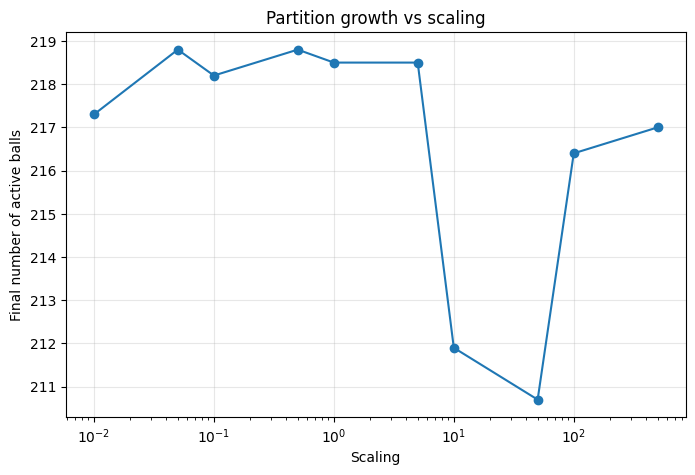

In [37]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

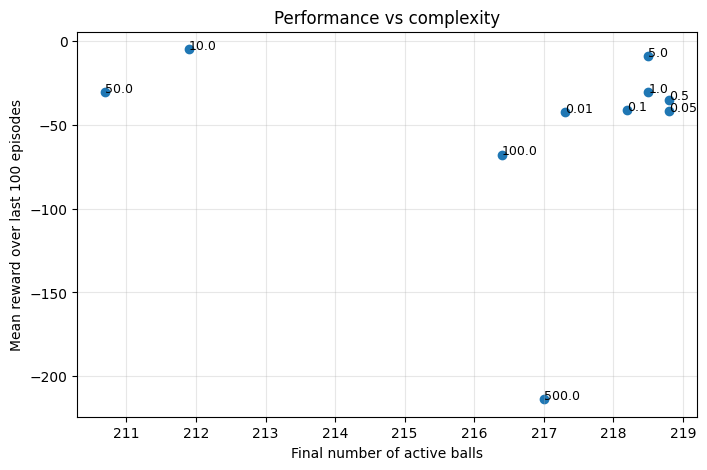

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: -41.462

--- Running: scaling=5 ---
    Done. Final mean VPI: -9.535

--- Running: scaling=100 ---
    Done. Final mean VPI: -68.414


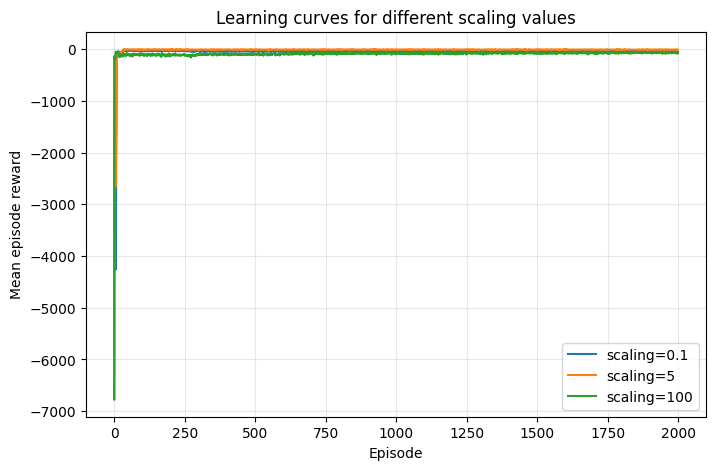

In [39]:
chosen_scalings = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")

plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

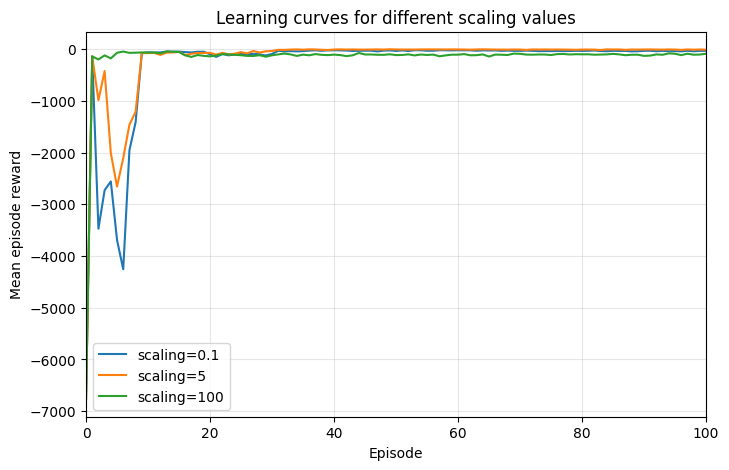

In [41]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")

plt.title("Learning curves for different scaling values")
plt.legend()
plt.xlim(0,100)
plt.grid(True, alpha=0.3)
plt.show()

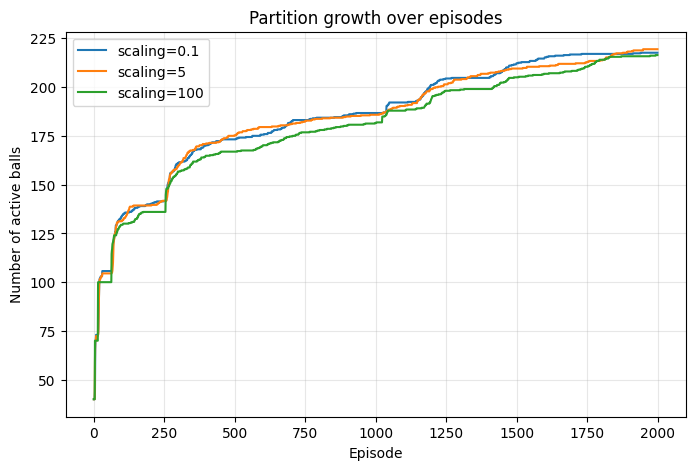

In [40]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()